In [1]:
%pip install earthengine-api geemap

Note: you may need to restart the kernel to use updated packages.


Packages loaded successfully.
Land-cover output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/landcover

Southwest Virginia boundary loaded.

Source file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/southwest_virginia_boundary.geojson

CRS:
EPSG:4326

Bounds:
[-83.67539511  36.54390066 -80.25        37.65      ]


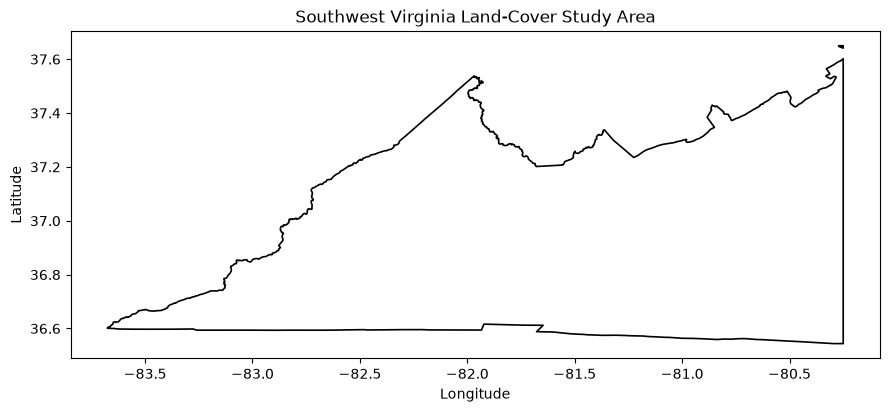

Earth Engine initialized using existing credentials.
Study boundary converted to Earth Engine geometry.

Available NLCD image IDs:
['2021']

NLCD land-cover image selected.

Bands:
['landcover']

Local raw NLCD file already exists.
Skipping Earth Engine Drive export.
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/landcover/raw/southwest_virginia_nlcd_2021_raw.tif

Expected local NLCD file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/landcover/raw/southwest_virginia_nlcd_2021_raw.tif

File exists:
True

Local NLCD file found.
File size in MB:
5.37

Raw NLCD information:
CRS: EPSG:5070
Width: 10045
Height: 5356
Bands: 1
Data type: ('uint8',)
Bounds: BoundingBox(left=1089270.0, bottom=1576740.0, right=1390620.0, top=1737420.0)
Resolution: (30.0, 30.0)
NoData: 0.0
Land-cover classes:
[11 21 22 23 24 31 41 42 43 52 71 81 82 90 95]

Standardized NLCD raster saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CA

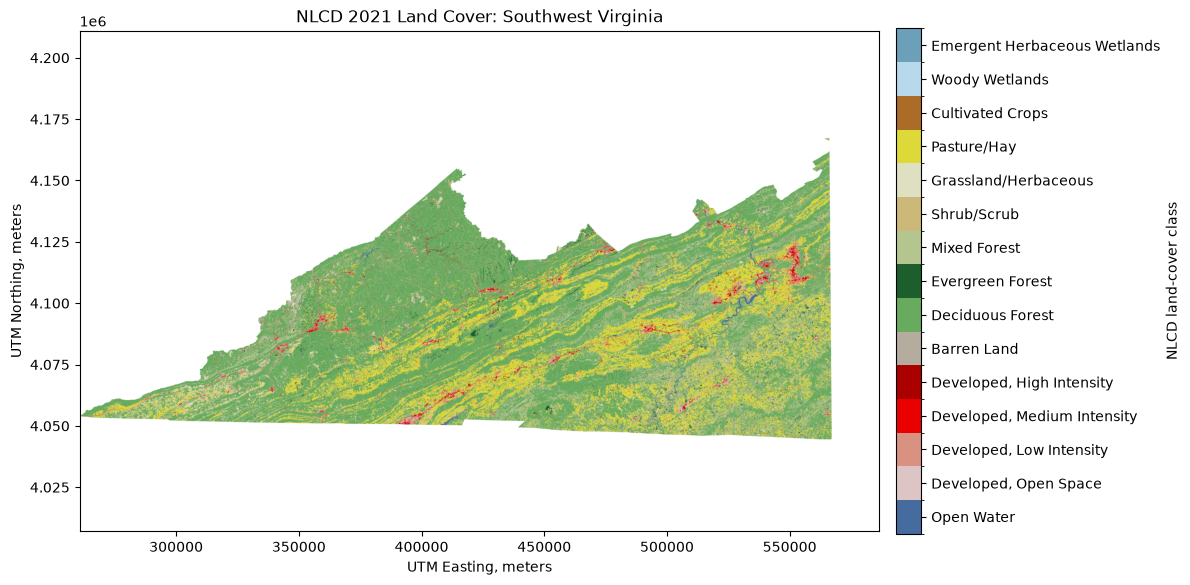


Land-cover map saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/landcover/southwest_virginia_nlcd_2021_map.png

Land-cover summary saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/landcover_summary.csv

Land-cover inventory saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/landcover_file_inventory.csv

NLCD LAND-COVER DOWNLOAD AND PROCESSING SUMMARY
Study boundary exists: True
Raw NLCD exists: True
Standardized NLCD exists: True
Processed UTM NLCD exists: True
Class-area table exists: True

Main land-cover raster:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/landcover/processed/southwest_virginia_nlcd_2021_utm17n.tif

Notebook completed successfully.


In [5]:
# =============================================================================
# 05_download_landcover.ipynb
#
# Purpose:
# Export USGS NLCD 2021 land-cover data for southwest Virginia from
# Google Earth Engine to Google Drive, then process the downloaded GeoTIFF
# locally.
#
# Important:
# Earth Engine exports the file to Google Drive. After the export completes,
# manually download the GeoTIFF into:
#
# /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/
# datasets/boundaries/landcover/raw/
# southwest_virginia_nlcd_2021_raw.tif
#
# Main output folder:
# /Users/gaoyujuan/REAP Dropbox/Gao yujuan/
# Virginia Tech/CALS/datasets/boundaries/landcover/
# =============================================================================


# =============================================================================
# 1. Load packages
# =============================================================================

from pathlib import Path
import json
import time

import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from matplotlib.colors import BoundaryNorm, ListedColormap
from rasterio.warp import (
    Resampling,
    calculate_default_transform,
    reproject,
)

print("Packages loaded successfully.")


# =============================================================================
# 2. Define project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

BOUNDARIES_DIR = BASE_DIR / "boundaries"
METADATA_DIR = BASE_DIR / "metadata"

DEM_DIR = BOUNDARIES_DIR / "dem"
LANDCOVER_DIR = BOUNDARIES_DIR / "landcover"

LANDCOVER_RAW_DIR = LANDCOVER_DIR / "raw"
LANDCOVER_PROCESSED_DIR = LANDCOVER_DIR / "processed"

for folder in [
    BOUNDARIES_DIR,
    METADATA_DIR,
    LANDCOVER_DIR,
    LANDCOVER_RAW_DIR,
    LANDCOVER_PROCESSED_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Land-cover output directory:")
print(LANDCOVER_DIR)


# =============================================================================
# 3. Define input and output files
# =============================================================================

SOUTHWEST_BOUNDARY_CANDIDATES = [
    DEM_DIR / "southwest_virginia_boundary.geojson",
    BOUNDARIES_DIR / "southwest_virginia_boundary.geojson",
]

SOUTHWEST_VIRGINIA_FILE = None

for candidate in SOUTHWEST_BOUNDARY_CANDIDATES:

    if candidate.exists():
        SOUTHWEST_VIRGINIA_FILE = candidate
        break


if SOUTHWEST_VIRGINIA_FILE is None:

    raise FileNotFoundError(
        "Southwest Virginia boundary was not found.\n"
        "Run 04_download_dem.ipynb first.\n\n"
        "Expected one of these files:\n"
        + "\n".join(
            str(path)
            for path in SOUTHWEST_BOUNDARY_CANDIDATES
        )
    )


RAW_NLCD_FILE = (
    LANDCOVER_RAW_DIR /
    "southwest_virginia_nlcd_2021_raw.tif"
)

PROCESSED_NLCD_WGS84_FILE = (
    LANDCOVER_PROCESSED_DIR /
    "southwest_virginia_nlcd_2021_wgs84.tif"
)

PROCESSED_NLCD_UTM_FILE = (
    LANDCOVER_PROCESSED_DIR /
    "southwest_virginia_nlcd_2021_utm17n.tif"
)

LANDCOVER_MAP_FILE = (
    LANDCOVER_DIR /
    "southwest_virginia_nlcd_2021_map.png"
)

CLASS_AREA_FILE = (
    METADATA_DIR /
    "southwest_virginia_nlcd_2021_class_area.csv"
)

LANDCOVER_SUMMARY_FILE = (
    METADATA_DIR /
    "landcover_summary.csv"
)

LANDCOVER_INVENTORY_FILE = (
    METADATA_DIR /
    "landcover_file_inventory.csv"
)


# =============================================================================
# 4. Load southwest Virginia boundary
# =============================================================================

southwest_virginia = gpd.read_file(
    SOUTHWEST_VIRGINIA_FILE
)

if southwest_virginia.crs is None:

    southwest_virginia = (
        southwest_virginia
        .set_crs("EPSG:4326")
    )

else:

    southwest_virginia = (
        southwest_virginia
        .to_crs("EPSG:4326")
    )


southwest_virginia = gpd.GeoDataFrame(
    {
        "study_area": [
            "southwest_virginia"
        ]
    },
    geometry=[
        southwest_virginia.geometry.union_all()
    ],
    crs="EPSG:4326",
)


print("\nSouthwest Virginia boundary loaded.")

print("\nSource file:")
print(SOUTHWEST_VIRGINIA_FILE)

print("\nCRS:")
print(southwest_virginia.crs)

print("\nBounds:")
print(southwest_virginia.total_bounds)


# =============================================================================
# 5. Plot the study boundary
# =============================================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

southwest_virginia.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
)

ax.set_title(
    "Southwest Virginia Land-Cover Study Area"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

plt.tight_layout()
plt.show()


# =============================================================================
# 6. Authenticate and initialize Google Earth Engine
#
# This must be your Google Cloud PROJECT ID, not the project name.
# =============================================================================

EARTH_ENGINE_PROJECT = "hurricane-504721"


try:

    ee.Initialize(
        project=EARTH_ENGINE_PROJECT
    )

    print(
        "Earth Engine initialized using "
        "existing credentials."
    )

except Exception as initialization_error:

    print(
        "Earth Engine authentication is required."
    )

    print(
        "Initial error:"
    )

    print(
        initialization_error
    )

    ee.Authenticate()

    ee.Initialize(
        project=EARTH_ENGINE_PROJECT
    )

    print(
        "Earth Engine authenticated and initialized."
    )


# =============================================================================
# 7. Convert the study boundary to an Earth Engine geometry
# =============================================================================

study_geojson = json.loads(
    southwest_virginia.to_json()
)

study_feature_collection = (
    ee.FeatureCollection(
        study_geojson
    )
)

study_geometry = (
    study_feature_collection.geometry()
)

print(
    "Study boundary converted to "
    "Earth Engine geometry."
)


# =============================================================================
# 8. Load USGS NLCD 2021
# =============================================================================

NLCD_COLLECTION_ID = (
    "USGS/NLCD_RELEASES/2021_REL/NLCD"
)

nlcd_collection = ee.ImageCollection(
    NLCD_COLLECTION_ID
)

image_ids = (
    nlcd_collection
    .aggregate_array(
        "system:index"
    )
    .getInfo()
)

print("\nAvailable NLCD image IDs:")
print(image_ids)


# =============================================================================
# 9. Select the 2021 NLCD image
# =============================================================================

if "2021" in image_ids:

    nlcd_image = (
        nlcd_collection
        .filter(
            ee.Filter.eq(
                "system:index",
                "2021",
            )
        )
        .first()
    )

else:

    print(
        "Warning: image index 2021 was not found. "
        "Using the most recent image."
    )

    nlcd_image = (
        nlcd_collection
        .sort(
            "system:time_start",
            False,
        )
        .first()
    )


nlcd_landcover = (
    ee.Image(
        nlcd_image
    )
    .select(
        "landcover"
    )
    .clip(
        study_geometry
    )
    .toUint8()
)


print("\nNLCD land-cover image selected.")

print("\nBands:")
print(
    nlcd_landcover
    .bandNames()
    .getInfo()
)


# =============================================================================
# 10. Export NLCD 2021 to Google Drive
#
# The direct local download can fail for a regional raster because Earth
# Engine limits direct-download dimensions and file size.
#
# This section creates a batch export to Google Drive.
#
# If the local file already exists, this section skips the Drive export.
# =============================================================================

DRIVE_FOLDER = (
    "CALS_Hurricane_Data"
)

EXPORT_DESCRIPTION = (
    "southwest_virginia_nlcd_2021"
)

DRIVE_FILE_PREFIX = (
    "southwest_virginia_nlcd_2021_raw"
)

export_task = None


if RAW_NLCD_FILE.exists():

    print(
        "\nLocal raw NLCD file already exists."
    )

    print(
        "Skipping Earth Engine Drive export."
    )

    print(
        RAW_NLCD_FILE
    )

else:

    print(
        "\nLocal raw NLCD file does not exist."
    )

    print(
        "Starting Earth Engine export to Google Drive..."
    )

    export_task = ee.batch.Export.image.toDrive(
        image=nlcd_landcover,
        description=EXPORT_DESCRIPTION,
        folder=DRIVE_FOLDER,
        fileNamePrefix=DRIVE_FILE_PREFIX,
        region=study_geometry,
        scale=30,
        crs="EPSG:5070",
        maxPixels=1_000_000_000,
        fileFormat="GeoTIFF",
        formatOptions={
            "cloudOptimized": True,
            "noData": 0,
        },
    )

    export_task.start()

    print(
        "\nEarth Engine export task started."
    )

    print(
        "Task ID:"
    )

    print(
        export_task.id
    )

    print(
        "\nGoogle Drive folder:"
    )

    print(
        DRIVE_FOLDER
    )

    print(
        "\nExpected filename:"
    )

    print(
        f"{DRIVE_FILE_PREFIX}.tif"
    )


# =============================================================================
# 11. Wait for the Google Drive export
#
# This section checks the export status every 15 seconds.
# It does not download the file from Google Drive to your Mac.
# =============================================================================

if export_task is not None:

    print(
        "\nWaiting for the Earth Engine export task..."
    )

    while export_task.active():

        task_status = export_task.status()

        print(
            "State:",
            task_status.get(
                "state"
            ),
            "| Description:",
            task_status.get(
                "description"
            ),
        )

        time.sleep(
            15
        )


    final_task_status = (
        export_task.status()
    )

    print(
        "\nFinal Earth Engine task status:"
    )

    print(
        final_task_status
    )


    if (
        final_task_status.get(
            "state"
        )
        != "COMPLETED"
    ):

        error_message = (
            final_task_status.get(
                "error_message"
            )
        )

        raise RuntimeError(
            "The Earth Engine Drive export did not complete.\n\n"
            f"Final state: "
            f"{final_task_status.get('state')}\n\n"
            f"Error message:\n"
            f"{error_message}"
        )


    print(
        "\nEarth Engine export completed successfully."
    )

    print(
        "\nNow download this file from Google Drive:"
    )

    print(
        f"My Drive/{DRIVE_FOLDER}/"
        f"{DRIVE_FILE_PREFIX}.tif"
    )

    print(
        "\nPlace it at:"
    )

    print(
        RAW_NLCD_FILE
    )


# =============================================================================
# 12. Confirm that the exported GeoTIFF exists locally
#
# Earth Engine exports to Google Drive, not directly to the Dropbox folder.
#
# After the Drive task completes:
#
# 1. Open Google Drive.
# 2. Open CALS_Hurricane_Data.
# 3. Download southwest_virginia_nlcd_2021_raw.tif.
# 4. Move it to the local raw folder shown below.
# 5. Rerun this notebook starting from this section.
# =============================================================================

print(
    "\nExpected local NLCD file:"
)

print(
    RAW_NLCD_FILE
)

print(
    "\nFile exists:"
)

print(
    RAW_NLCD_FILE.exists()
)


if not RAW_NLCD_FILE.exists():

    raise FileNotFoundError(
        "The Earth Engine export may have completed, but the GeoTIFF "
        "has not been downloaded from Google Drive to the local project "
        "folder yet.\n\n"
        "Download this file from Google Drive:\n"
        f"My Drive/{DRIVE_FOLDER}/{DRIVE_FILE_PREFIX}.tif\n\n"
        "Place it at this exact path:\n"
        f"{RAW_NLCD_FILE}\n\n"
        "Then rerun this notebook beginning with Section 12."
    )


file_size_mb = (
    RAW_NLCD_FILE.stat().st_size
    / 1024
    / 1024
)

print(
    "\nLocal NLCD file found."
)

print(
    "File size in MB:"
)

print(
    round(
        file_size_mb,
        2,
    )
)


# =============================================================================
# 13. Inspect the downloaded raster
# =============================================================================

with rasterio.open(
    RAW_NLCD_FILE
) as src:

    raw_landcover = src.read(
        1,
        masked=True,
    )

    print("\nRaw NLCD information:")

    print(
        "CRS:",
        src.crs,
    )

    print(
        "Width:",
        src.width,
    )

    print(
        "Height:",
        src.height,
    )

    print(
        "Bands:",
        src.count,
    )

    print(
        "Data type:",
        src.dtypes,
    )

    print(
        "Bounds:",
        src.bounds,
    )

    print(
        "Resolution:",
        src.res,
    )

    print(
        "NoData:",
        src.nodata,
    )


    valid_values = (
        raw_landcover.compressed()
    )


    if valid_values.size > 0:

        print(
            "Land-cover classes:"
        )

        print(
            np.unique(
                valid_values
            )
        )


# =============================================================================
# 14. Create a standardized local raster
#
# The Earth Engine export uses EPSG:5070 because it is appropriate for
# continental U.S. land-cover data. The filename retains "wgs84" only for
# compatibility with the earlier workflow, but the actual CRS is preserved
# from the Earth Engine export.
# =============================================================================

with rasterio.open(
    RAW_NLCD_FILE
) as src:

    landcover_array = src.read(
        1
    )

    output_metadata = (
        src.meta.copy()
    )


    if np.issubdtype(
        landcover_array.dtype,
        np.floating,
    ):

        invalid_mask = (
            ~np.isfinite(
                landcover_array
            )
        )

        landcover_array[
            invalid_mask
        ] = 0


    if src.nodata is not None:

        landcover_array[
            landcover_array
            == src.nodata
        ] = 0


    landcover_array = (
        landcover_array
        .astype(
            "uint8"
        )
    )


    output_metadata.update(
        {
            "dtype": "uint8",
            "count": 1,
            "nodata": 0,
            "compress": "lzw",
        }
    )


    with rasterio.open(
        PROCESSED_NLCD_WGS84_FILE,
        "w",
        **output_metadata,
    ) as destination:

        destination.write(
            landcover_array,
            1,
        )


print(
    "\nStandardized NLCD raster saved to:"
)

print(
    PROCESSED_NLCD_WGS84_FILE
)


# =============================================================================
# 15. Reproject NLCD to UTM Zone 17N
#
# This matches the projected CRS used in the DEM workflow.
#
# Nearest-neighbor resampling is required because NLCD is categorical.
# =============================================================================

TARGET_CRS = (
    "EPSG:32617"
)


with rasterio.open(
    PROCESSED_NLCD_WGS84_FILE
) as src:

    transform, width, height = (
        calculate_default_transform(
            src.crs,
            TARGET_CRS,
            src.width,
            src.height,
            *src.bounds,
        )
    )


    projected_metadata = (
        src.meta.copy()
    )


    projected_metadata.update(
        {
            "crs": TARGET_CRS,
            "transform": transform,
            "width": width,
            "height": height,
            "dtype": "uint8",
            "nodata": 0,
            "compress": "lzw",
        }
    )


    with rasterio.open(
        PROCESSED_NLCD_UTM_FILE,
        "w",
        **projected_metadata,
    ) as destination:

        reproject(
            source=rasterio.band(
                src,
                1,
            ),
            destination=rasterio.band(
                destination,
                1,
            ),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=TARGET_CRS,
            resampling=Resampling.nearest,
            src_nodata=0,
            dst_nodata=0,
        )


print(
    "\nProjected NLCD raster saved to:"
)

print(
    PROCESSED_NLCD_UTM_FILE
)


# =============================================================================
# 16. Define NLCD classes
# =============================================================================

NLCD_CLASSES = {
    11: "Open Water",
    12: "Perennial Ice/Snow",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    51: "Dwarf Scrub",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    72: "Sedge/Herbaceous",
    73: "Lichens",
    74: "Moss",
    81: "Pasture/Hay",
    82: "Cultivated Crops",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
}


# =============================================================================
# 17. Define NLCD display colors
# =============================================================================

NLCD_COLORS = {
    11: "#466B9F",
    12: "#D1DEF8",
    21: "#DEC5C5",
    22: "#D99282",
    23: "#EB0000",
    24: "#AB0000",
    31: "#B3AC9F",
    41: "#68AB5F",
    42: "#1C5F2C",
    43: "#B5C58F",
    51: "#AF963C",
    52: "#CCB879",
    71: "#DFDFC2",
    72: "#D1D182",
    73: "#A3CC51",
    74: "#82BA9E",
    81: "#DCD939",
    82: "#AB6C28",
    90: "#B8D9EB",
    95: "#6C9FB8",
}


# =============================================================================
# 18. Calculate land-cover class areas
# =============================================================================

with rasterio.open(
    PROCESSED_NLCD_UTM_FILE
) as src:

    landcover = src.read(
        1,
        masked=True,
    )

    pixel_width = abs(
        src.transform.a
    )

    pixel_height = abs(
        src.transform.e
    )

    pixel_area_m2 = (
        pixel_width
        * pixel_height
    )

    valid_values = (
        landcover.compressed()
    )

    valid_values = (
        valid_values[
            valid_values != 0
        ]
    )


    class_codes, class_counts = (
        np.unique(
            valid_values,
            return_counts=True,
        )
    )


class_area_records = []

total_valid_pixels = int(
    class_counts.sum()
)


for class_code, pixel_count in zip(
    class_codes,
    class_counts,
):

    class_code = int(
        class_code
    )

    pixel_count = int(
        pixel_count
    )

    area_m2 = (
        pixel_count
        * pixel_area_m2
    )

    area_km2 = (
        area_m2
        / 1_000_000
    )

    percentage = (
        pixel_count
        / total_valid_pixels
        * 100
    )


    class_area_records.append(
        {
            "nlcd_class": class_code,
            "class_name": (
                NLCD_CLASSES.get(
                    class_code,
                    "Unknown",
                )
            ),
            "pixel_count": pixel_count,
            "area_square_meters": area_m2,
            "area_square_kilometers": area_km2,
            "percent_of_valid_area": percentage,
        }
    )


class_area = pd.DataFrame(
    class_area_records
)

class_area = (
    class_area
    .sort_values(
        "area_square_kilometers",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


class_area.to_csv(
    CLASS_AREA_FILE,
    index=False,
)


print(
    "\nLand-cover class areas:"
)

print(
    class_area
)

print(
    "\nClass-area table saved to:"
)

print(
    CLASS_AREA_FILE
)


# =============================================================================
# 19. Plot the land-cover raster
# =============================================================================

with rasterio.open(
    PROCESSED_NLCD_UTM_FILE
) as src:

    landcover_plot = src.read(
        1,
        masked=True,
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]


present_classes = sorted(
    [
        int(value)
        for value in np.unique(
            landcover_plot.compressed()
        )
        if (
            int(value) != 0
            and int(value) in NLCD_CLASSES
        )
    ]
)


if not present_classes:

    raise RuntimeError(
        "No recognized NLCD classes were found "
        "in the processed raster."
    )


display_colors = [
    NLCD_COLORS[
        class_code
    ]
    for class_code in present_classes
]


display_labels = [
    NLCD_CLASSES[
        class_code
    ]
    for class_code in present_classes
]


class_to_index = {
    class_code: index
    for index, class_code
    in enumerate(
        present_classes
    )
}


indexed_array = np.full(
    landcover_plot.shape,
    np.nan,
    dtype="float32",
)


for class_code, index in class_to_index.items():

    indexed_array[
        landcover_plot
        == class_code
    ] = index


cmap = ListedColormap(
    display_colors
)


bounds = np.arange(
    -0.5,
    len(present_classes) + 0.5,
    1,
)


norm = BoundaryNorm(
    bounds,
    cmap.N,
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)


image = ax.imshow(
    indexed_array,
    extent=extent,
    cmap=cmap,
    norm=norm,
)


ax.set_title(
    "NLCD 2021 Land Cover: Southwest Virginia"
)


ax.set_xlabel(
    "UTM Easting, meters"
)


ax.set_ylabel(
    "UTM Northing, meters"
)


colorbar = plt.colorbar(
    image,
    ax=ax,
    boundaries=bounds,
    ticks=np.arange(
        len(
            present_classes
        )
    ),
    fraction=0.03,
    pad=0.02,
)


colorbar.ax.set_yticklabels(
    display_labels
)


colorbar.set_label(
    "NLCD land-cover class"
)


plt.tight_layout()


plt.savefig(
    LANDCOVER_MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    "\nLand-cover map saved to:"
)

print(
    LANDCOVER_MAP_FILE
)


# =============================================================================
# 20. Create land-cover summary metadata
# =============================================================================

with rasterio.open(
    PROCESSED_NLCD_UTM_FILE
) as src:

    processed_landcover = src.read(
        1,
        masked=True,
    )

    valid_classes = np.unique(
        processed_landcover.compressed()
    )

    valid_classes = (
        valid_classes[
            valid_classes != 0
        ]
    )


    summary = {
        "dataset": (
            "USGS NLCD 2021"
        ),
        "study_area": (
            "Southwest Virginia"
        ),
        "earth_engine_project": (
            EARTH_ENGINE_PROJECT
        ),
        "source_collection": (
            NLCD_COLLECTION_ID
        ),
        "source_boundary": str(
            SOUTHWEST_VIRGINIA_FILE
        ),
        "output_crs": str(
            src.crs
        ),
        "width": (
            src.width
        ),
        "height": (
            src.height
        ),
        "resolution_x": (
            src.res[0]
        ),
        "resolution_y": (
            src.res[1]
        ),
        "number_of_classes": (
            len(
                valid_classes
            )
        ),
        "raw_file": str(
            RAW_NLCD_FILE
        ),
        "standardized_file": str(
            PROCESSED_NLCD_WGS84_FILE
        ),
        "processed_utm_file": str(
            PROCESSED_NLCD_UTM_FILE
        ),
    }


landcover_summary = pd.DataFrame(
    [summary]
)


landcover_summary.to_csv(
    LANDCOVER_SUMMARY_FILE,
    index=False,
)


print(
    "\nLand-cover summary saved to:"
)

print(
    LANDCOVER_SUMMARY_FILE
)


# =============================================================================
# 21. Create file inventory
# =============================================================================

inventory_records = []


for file in sorted(
    LANDCOVER_DIR.rglob("*")
):

    if file.is_file():

        inventory_records.append(
            {
                "file_name": (
                    file.name
                ),
                "extension": (
                    file.suffix.lower()
                ),
                "file_path": (
                    str(file)
                ),
                "file_size_bytes": (
                    file.stat().st_size
                ),
            }
        )


landcover_inventory = pd.DataFrame(
    inventory_records
)


landcover_inventory.to_csv(
    LANDCOVER_INVENTORY_FILE,
    index=False,
)


print(
    "\nLand-cover inventory saved to:"
)

print(
    LANDCOVER_INVENTORY_FILE
)


# =============================================================================
# 22. Final validation
# =============================================================================

print(
    "\n"
    + "=" * 75
)

print(
    "NLCD LAND-COVER DOWNLOAD AND PROCESSING SUMMARY"
)

print(
    "=" * 75
)


print(
    f"Study boundary exists: "
    f"{SOUTHWEST_VIRGINIA_FILE.exists()}"
)


print(
    f"Raw NLCD exists: "
    f"{RAW_NLCD_FILE.exists()}"
)


print(
    f"Standardized NLCD exists: "
    f"{PROCESSED_NLCD_WGS84_FILE.exists()}"
)


print(
    f"Processed UTM NLCD exists: "
    f"{PROCESSED_NLCD_UTM_FILE.exists()}"
)


print(
    f"Class-area table exists: "
    f"{CLASS_AREA_FILE.exists()}"
)


print(
    "\nMain land-cover raster:"
)

print(
    PROCESSED_NLCD_UTM_FILE
)


print(
    "\nNotebook completed successfully."
)